In [1]:
#------使用XGB模型-透射光谱-使用光谱预处理方法-融合RGB------#
#------储存路径代号：XGB_Fusion_01------#

In [2]:
import os
import sys
from pathlib import Path
project_root = Path('/home/liudaolong/Project/07-Honey')
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from utils.train_log import EvaluationMetricsLogger,PredictionSaver
from utils import datalodaer,model_trainer,preprocess,utils,ploter

import pandas as pd
import numpy as np
from datetime import datetime

# 设置全局字体为 "Times New Roman"
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 9         # 设置全局字体大小
plt.rcParams['axes.unicode_minus'] = False  # 设置支持负号显示
plt.rcParams['svg.fonttype'] = 'none'

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

series_path = '04-XGBoost-TS&RGB-Preprocessing'

In [3]:
spectra_path = project_root / 'data/spectra/Spectra_TS_wavelength.csv'
labels_file = project_root / 'data/labels'
image_features_path = project_root / 'data/pictures/rgb_features.csv'
logger = EvaluationMetricsLogger()
saver = PredictionSaver()


In [4]:
# 定义预处理方法字典
preprocess_methods = {
    "Raw":          preprocess.DummyTransformer(),  # 原始数据
    "Detrend":      preprocess.Detrend(type='linear'), # 线性基线校正
    "SNV":          preprocess.SNV(),               # 标准正态变量变换
    "MSC":          preprocess.MSC(),               # 多元散射校正
    "SG_1":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=1), # 一阶导
    "SG_2":         preprocess.SavitzkyGolay(window_length=15, polyorder=3, deriv=2)  # 二阶导
}

[I 2026-01-21 23:17:49,998] A new study created in memory with name: xgb_optuna_tuning


NO.1 [正在训练: PH | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 93
  最优参数: {'learning_rate': 0.010673523036541274, 'max_depth': 5, 'min_child_weight': 3.2963074007866133, 'subsample': 0.5470068764220666, 'colsample_bytree': 0.894040650971897, 'reg_lambda': 0.026803249923959792, 'reg_alpha': 0.03516099108337484, 'gamma': 0.015782633055015812}
  最优验证集 RMSE: 0.07777248322963715
  对应 best_iteration: 386
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.8609, 验证集 R²: 0.6074, 测试集 R²: 0.4260



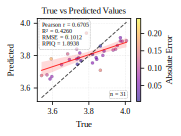

NO.2 [正在训练: PH | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 22
  最优参数: {'learning_rate': 0.07060004329432264, 'max_depth': 7, 'min_child_weight': 5.01758886538154, 'subsample': 0.7082790818032587, 'colsample_bytree': 0.6770175693937242, 'reg_lambda': 0.12562092368400096, 'reg_alpha': 0.010751153283702597, 'gamma': 0.0012039972377606532}
  最优验证集 RMSE: 0.07762132585048676
  对应 best_iteration: 63
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9788, 验证集 R²: 0.6089, 测试集 R²: 0.5453



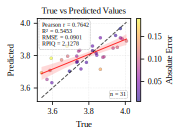

NO.3 [正在训练: PH | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 88
  最优参数: {'learning_rate': 0.026589890786439283, 'max_depth': 6, 'min_child_weight': 9.653159655486872, 'subsample': 0.5371481221314226, 'colsample_bytree': 0.8308755547199108, 'reg_lambda': 0.02076374908312211, 'reg_alpha': 0.008217372365712686, 'gamma': 0.004077851311419817}
  最优验证集 RMSE: 0.09097125381231308
  对应 best_iteration: 197
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9372, 验证集 R²: 0.4628, 测试集 R²: 0.2986



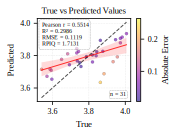

NO.4 [正在训练: PH | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 94
  最优参数: {'learning_rate': 0.03330971326613683, 'max_depth': 5, 'min_child_weight': 8.03791043636468, 'subsample': 0.5648219660402231, 'colsample_bytree': 0.8301983770154172, 'reg_lambda': 0.01242779273101645, 'reg_alpha': 0.014995543975455434, 'gamma': 0.012301842702031439}
  最优验证集 RMSE: 0.09013643115758896
  对应 best_iteration: 87
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.8722, 验证集 R²: 0.4726, 测试集 R²: 0.3834



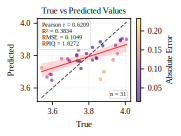

NO.5 [正在训练: PH | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.022351695219263914, 'max_depth': 8, 'min_child_weight': 1.5963734280589197, 'subsample': 0.5708494387251676, 'colsample_bytree': 0.5367289857450996, 'reg_lambda': 0.01813582476672022, 'reg_alpha': 0.04008968054486192, 'gamma': 0.00015457083878103826}
  最优验证集 RMSE: 0.07284180074930191
  对应 best_iteration: 210
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9876, 验证集 R²: 0.6556, 测试集 R²: 0.6834



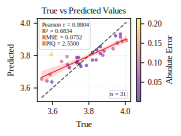

NO.6 [正在训练: PH | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 25
  最优参数: {'learning_rate': 0.06830722417428445, 'max_depth': 8, 'min_child_weight': 6.403889612535535, 'subsample': 0.7048143740473232, 'colsample_bytree': 0.8703790683541198, 'reg_lambda': 0.01650251202963039, 'reg_alpha': 0.009650937966264315, 'gamma': 0.005000479628619818}
  最优验证集 RMSE: 0.0619606152176857
  对应 best_iteration: 87
预测结果已保存OK
实验记录已保存: PH-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9800, 验证集 R²: 0.7508, 测试集 R²: 0.6292



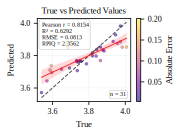

NO.7 [正在训练: GLU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 43
  最优参数: {'learning_rate': 0.06824653761562267, 'max_depth': 6, 'min_child_weight': 9.30234798851818, 'subsample': 0.5373839017498561, 'colsample_bytree': 0.4874509418932388, 'reg_lambda': 0.3892629982235451, 'reg_alpha': 0.12303285732117583, 'gamma': 0.12630789209851645}
  最优验证集 RMSE: 1.7794188261032104
  对应 best_iteration: 39
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.8352, 验证集 R²: 0.6710, 测试集 R²: 0.6459



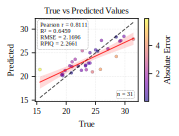

NO.8 [正在训练: GLU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 89
  最优参数: {'learning_rate': 0.030870233029471845, 'max_depth': 7, 'min_child_weight': 8.240024790313422, 'subsample': 0.5125352272127143, 'colsample_bytree': 0.473756351267196, 'reg_lambda': 37.280538908992845, 'reg_alpha': 0.00958810566910966, 'gamma': 0.268909096943063}
  最优验证集 RMSE: 1.5268880128860474
  对应 best_iteration: 1012
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9597, 验证集 R²: 0.7577, 测试集 R²: 0.7164



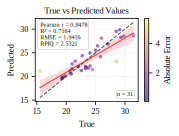

NO.9 [正在训练: GLU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 26
  最优参数: {'learning_rate': 0.04442528644391043, 'max_depth': 4, 'min_child_weight': 8.514498146631308, 'subsample': 0.7061263810064461, 'colsample_bytree': 0.9183604973777273, 'reg_lambda': 0.05093842061847427, 'reg_alpha': 1.4682039470975734, 'gamma': 2.8189424980106983}
  最优验证集 RMSE: 1.5352904796600342
  对应 best_iteration: 91
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9230, 验证集 R²: 0.7550, 测试集 R²: 0.7100



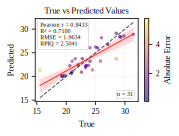

NO.10 [正在训练: GLU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 97
  最优参数: {'learning_rate': 0.045222550560441256, 'max_depth': 2, 'min_child_weight': 6.035979145523622, 'subsample': 0.6156976860757468, 'colsample_bytree': 0.9175732252878152, 'reg_lambda': 0.0020345972669163874, 'reg_alpha': 0.0011019938071789887, 'gamma': 2.339005346749209}
  最优验证集 RMSE: 1.4969964027404785
  对应 best_iteration: 200
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9626, 验证集 R²: 0.7671, 测试集 R²: 0.7199



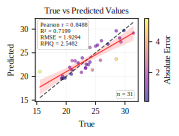

NO.11 [正在训练: GLU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 65
  最优参数: {'learning_rate': 0.062098484846306444, 'max_depth': 5, 'min_child_weight': 3.789125489195115, 'subsample': 0.5373393399262019, 'colsample_bytree': 0.902243765660461, 'reg_lambda': 21.98908709561101, 'reg_alpha': 0.021229055622860288, 'gamma': 1.6330631733470367}
  最优验证集 RMSE: 1.4977079629898071
  对应 best_iteration: 199
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9410, 验证集 R²: 0.7669, 测试集 R²: 0.7073



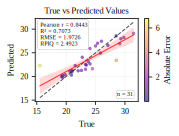

NO.12 [正在训练: GLU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 88
  最优参数: {'learning_rate': 0.0023291967329998197, 'max_depth': 7, 'min_child_weight': 8.456821665719376, 'subsample': 0.5027650383635514, 'colsample_bytree': 0.8194721339302299, 'reg_lambda': 0.08794846395875264, 'reg_alpha': 0.06744966161222485, 'gamma': 0.017162753261518948}
  最优验证集 RMSE: 1.3272693157196045
  对应 best_iteration: 4101
预测结果已保存OK
实验记录已保存: GLU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9902, 验证集 R²: 0.8169, 测试集 R²: 0.7820



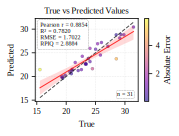

NO.13 [正在训练: 5-HMF | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 90
  最优参数: {'learning_rate': 0.02237668958408926, 'max_depth': 5, 'min_child_weight': 1.947161531829947, 'subsample': 0.9355013682269224, 'colsample_bytree': 0.5922898050073824, 'reg_lambda': 0.4527425764416174, 'reg_alpha': 2.3859365510460533, 'gamma': 0.6033137160226514}
  最优验证集 RMSE: 14.667421340942383
  对应 best_iteration: 202
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9961, 验证集 R²: 0.9833, 测试集 R²: 0.8559



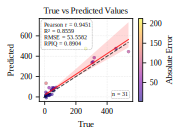

NO.14 [正在训练: 5-HMF | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 79
  最优参数: {'learning_rate': 0.02047656926794542, 'max_depth': 6, 'min_child_weight': 2.475824889948136, 'subsample': 0.8309878512328759, 'colsample_bytree': 0.42427803019446814, 'reg_lambda': 7.839423022788874, 'reg_alpha': 0.5524524140762074, 'gamma': 2.2939068852267805}
  最优验证集 RMSE: 16.762088775634766
  对应 best_iteration: 282
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9671, 验证集 R²: 0.9782, 测试集 R²: 0.9527



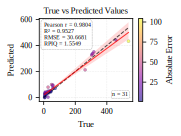

NO.15 [正在训练: 5-HMF | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 94
  最优参数: {'learning_rate': 0.05440100300167652, 'max_depth': 8, 'min_child_weight': 1.6367767839027316, 'subsample': 0.8140819962050112, 'colsample_bytree': 0.8898072222944619, 'reg_lambda': 47.56160423263719, 'reg_alpha': 0.23868182327593654, 'gamma': 0.13718799566698509}
  最优验证集 RMSE: 21.73746109008789
  对应 best_iteration: 281
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9499, 验证集 R²: 0.9634, 测试集 R²: 0.9342



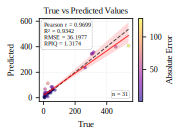

NO.16 [正在训练: 5-HMF | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 75
  最优参数: {'learning_rate': 0.004670459215920272, 'max_depth': 3, 'min_child_weight': 1.9588359527066062, 'subsample': 0.5898021568358647, 'colsample_bytree': 0.6923556996140242, 'reg_lambda': 27.0445299101233, 'reg_alpha': 0.003942795786014161, 'gamma': 0.3976417364909479}
  最优验证集 RMSE: 22.156200408935547
  对应 best_iteration: 2934
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9434, 验证集 R²: 0.9620, 测试集 R²: 0.9435



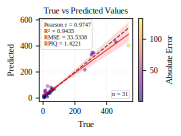

NO.17 [正在训练: 5-HMF | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 80
  最优参数: {'learning_rate': 0.016079190709307863, 'max_depth': 6, 'min_child_weight': 1.2555600046533426, 'subsample': 0.9556303722072187, 'colsample_bytree': 0.8448891054135662, 'reg_lambda': 9.818577209742116, 'reg_alpha': 0.662620795011287, 'gamma': 3.6165583680564195}
  最优验证集 RMSE: 14.542903900146484
  对应 best_iteration: 666
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9975, 验证集 R²: 0.9836, 测试集 R²: 0.9565



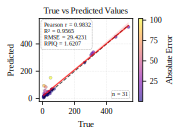

NO.18 [正在训练: 5-HMF | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 98
  最优参数: {'learning_rate': 0.02338593544092464, 'max_depth': 3, 'min_child_weight': 5.815728115941969, 'subsample': 0.7255571574192486, 'colsample_bytree': 0.39710061488844406, 'reg_lambda': 34.88621162293993, 'reg_alpha': 0.07146783147614588, 'gamma': 0.7147449177174044}
  最优验证集 RMSE: 25.840620040893555
  对应 best_iteration: 485
预测结果已保存OK
实验记录已保存: 5-HMF-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9451, 验证集 R²: 0.9483, 测试集 R²: 0.9251



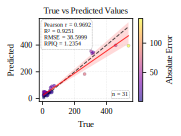

NO.19 [正在训练: Water | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 86
  最优参数: {'learning_rate': 0.009835856682693728, 'max_depth': 2, 'min_child_weight': 1.3646895446905871, 'subsample': 0.6265990372733297, 'colsample_bytree': 0.9978055609734526, 'reg_lambda': 0.0017464916724675046, 'reg_alpha': 0.005568081883688801, 'gamma': 0.2748834345753289}
  最优验证集 RMSE: 0.8274977803230286
  对应 best_iteration: 886
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9973, 验证集 R²: 0.9638, 测试集 R²: 0.9667



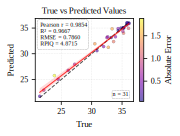

NO.20 [正在训练: Water | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 65
  最优参数: {'learning_rate': 0.024293219912437956, 'max_depth': 8, 'min_child_weight': 9.957346912169827, 'subsample': 0.7512108500823556, 'colsample_bytree': 0.3907214397054658, 'reg_lambda': 0.10807379573175799, 'reg_alpha': 0.3368930117989426, 'gamma': 1.1067241473930474}
  最优验证集 RMSE: 0.8709130883216858
  对应 best_iteration: 206
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9898, 验证集 R²: 0.9599, 测试集 R²: 0.9644



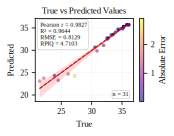

NO.21 [正在训练: Water | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 83
  最优参数: {'learning_rate': 0.0047078289007034795, 'max_depth': 7, 'min_child_weight': 2.055766338078211, 'subsample': 0.5424420713794491, 'colsample_bytree': 0.7469482983647646, 'reg_lambda': 1.5256536381446746, 'reg_alpha': 0.12821181598966966, 'gamma': 0.11672265571906915}
  最优验证集 RMSE: 0.7267532348632812
  对应 best_iteration: 989
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9938, 验证集 R²: 0.9721, 测试集 R²: 0.9350



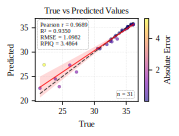

NO.22 [正在训练: Water | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 87
  最优参数: {'learning_rate': 0.04998049520209812, 'max_depth': 4, 'min_child_weight': 1.6983499492065561, 'subsample': 0.6338787670469186, 'colsample_bytree': 0.7071452415024428, 'reg_lambda': 2.5215993677738764, 'reg_alpha': 0.3043437397602199, 'gamma': 0.9523410628684048}
  最优验证集 RMSE: 0.5631222128868103
  对应 best_iteration: 258
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9953, 验证集 R²: 0.9833, 测试集 R²: 0.9663



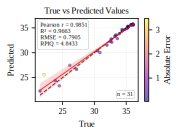

NO.23 [正在训练: Water | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 59
  最优参数: {'learning_rate': 0.019187639800360142, 'max_depth': 4, 'min_child_weight': 6.74253840507499, 'subsample': 0.6957933331859684, 'colsample_bytree': 0.46657693415466084, 'reg_lambda': 0.3276410077950888, 'reg_alpha': 0.03878925746575356, 'gamma': 0.6688622191931214}
  最优验证集 RMSE: 0.6046223640441895
  对应 best_iteration: 536
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9975, 验证集 R²: 0.9807, 测试集 R²: 0.9900



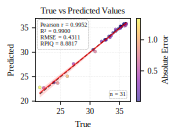

NO.24 [正在训练: Water | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 81
  最优参数: {'learning_rate': 0.001961182615621687, 'max_depth': 8, 'min_child_weight': 8.399102116020298, 'subsample': 0.67323385017432, 'colsample_bytree': 0.9479846296070483, 'reg_lambda': 0.06025110417684269, 'reg_alpha': 0.06969232789982376, 'gamma': 0.19651267438218273}
  最优验证集 RMSE: 0.5883231163024902
  对应 best_iteration: 3963
预测结果已保存OK
实验记录已保存: Water-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9984, 验证集 R²: 0.9817, 测试集 R²: 0.9891



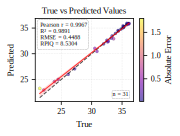

NO.25 [正在训练: FRU | 预处理: Raw]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 75
  最优参数: {'learning_rate': 0.003953463024330983, 'max_depth': 5, 'min_child_weight': 9.205296360149855, 'subsample': 0.6238461099550856, 'colsample_bytree': 0.8601170260128603, 'reg_lambda': 0.22946899516543084, 'reg_alpha': 0.14298851817427577, 'gamma': 0.48426525237656315}
  最优验证集 RMSE: 2.5398478507995605
  对应 best_iteration: 484
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.7749, 验证集 R²: 0.6337, 测试集 R²: 0.5195



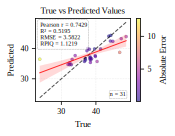

NO.26 [正在训练: FRU | 预处理: Detrend]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 67
  最优参数: {'learning_rate': 0.08717668112828167, 'max_depth': 4, 'min_child_weight': 9.238922798298313, 'subsample': 0.9518289813858761, 'colsample_bytree': 0.38405523015193793, 'reg_lambda': 0.014043669322133873, 'reg_alpha': 0.012024360047671151, 'gamma': 3.9563423866584047}
  最优验证集 RMSE: 2.4548466205596924
  对应 best_iteration: 28
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9123, 验证集 R²: 0.6578, 测试集 R²: 0.5769



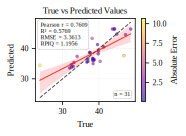

NO.27 [正在训练: FRU | 预处理: SNV]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 80
  最优参数: {'learning_rate': 0.0555033468078947, 'max_depth': 2, 'min_child_weight': 2.061776230598642, 'subsample': 0.8634569424288071, 'colsample_bytree': 0.7416852262248295, 'reg_lambda': 0.002470203850818589, 'reg_alpha': 0.04390587986982163, 'gamma': 0.00013610783239309532}
  最优验证集 RMSE: 2.4759488105773926
  对应 best_iteration: 44
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.8724, 验证集 R²: 0.6519, 测试集 R²: 0.5781



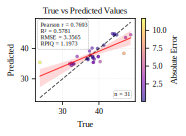

NO.28 [正在训练: FRU | 预处理: MSC]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 85
  最优参数: {'learning_rate': 0.0110098013148852, 'max_depth': 7, 'min_child_weight': 2.6969198886044623, 'subsample': 0.9998528480266458, 'colsample_bytree': 0.8112440182874354, 'reg_lambda': 0.017410339935070754, 'reg_alpha': 0.0014224848090994887, 'gamma': 2.3287793346983627}
  最优验证集 RMSE: 2.4384350776672363
  对应 best_iteration: 122
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9123, 验证集 R²: 0.6624, 测试集 R²: 0.5600



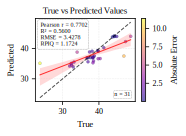

NO.29 [正在训练: FRU | 预处理: SG_1]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 82
  最优参数: {'learning_rate': 0.089630999354133, 'max_depth': 8, 'min_child_weight': 9.070403572248251, 'subsample': 0.5091007088670819, 'colsample_bytree': 0.8173492576404813, 'reg_lambda': 1.8821330455762741, 'reg_alpha': 6.2436251517596295, 'gamma': 0.6934731688822218}
  最优验证集 RMSE: 2.252912998199463
  对应 best_iteration: 90
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9305, 验证集 R²: 0.7118, 测试集 R²: 0.4991



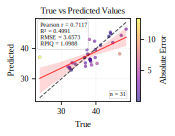

NO.30 [正在训练: FRU | 预处理: SG_2]========================


  0%|          | 0/100 [00:00<?, ?it/s]

Optuna 调参完成：
  最优 trial 编号: 16
  最优参数: {'learning_rate': 0.03821080341362487, 'max_depth': 2, 'min_child_weight': 3.6587668582832777, 'subsample': 0.5829793668662153, 'colsample_bytree': 0.9960872454571172, 'reg_lambda': 1.259819524833916, 'reg_alpha': 0.09951497739153958, 'gamma': 2.807516649085973}
  最优验证集 RMSE: 2.0897746086120605
  对应 best_iteration: 221
预测结果已保存OK
实验记录已保存: FRU-04-XGBoost-TS&RGB-Preprocessing
训练集 R²: 0.9839, 验证集 R²: 0.7520, 测试集 R²: 0.6322



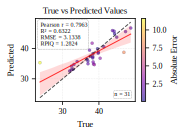

所有模型及预处理对比训练完成！


In [5]:
# 遍历所有 Label 文件
i = 0
for filename in os.listdir(labels_file):
    if filename.endswith(('.csv',)):
        label_path = os.path.join(labels_file, filename)
        label_name = os.path.splitext(filename)[0]

        # 读取并分割数据 (只需做一次)
        try:
            # 1. 加载、对齐数据，并划分数据集
            train_set, val_set, test_set = datalodaer.fused_data_split(spectra_path, image_features_path, label_path)
            # 每个set包含(X_spec, X_image, y, idx)
            # 2. 内部循环：遍历预处理方法
            for prep_name, prep_obj in preprocess_methods.items():
                i += 1
                print(f"NO.{i} [正在训练: {label_name} | 预处理: {prep_name}]========================")

                # =========================================
                # A. 数据融合处理 (关键步骤)
                # =========================================
                # 1. 光谱部分: 应用特定的预处理 (fit on train, transform all)
                spec_train_trans = prep_obj.fit_transform(train_set[0])
                spec_val_trans = prep_obj.transform(val_set[0])
                spec_test_trans = prep_obj.transform(test_set[0])

                # 2. 图像特征部分: 标准化 (XGB内无StandardScaler)
                scaler = StandardScaler()
                image_train_trans = scaler.fit_transform(train_set[1])
                image_val_trans = scaler.transform(val_set[1])
                image_test_trans = scaler.transform(test_set[1])

                # 3. 特征级融合 (Concatenation)
                X_train_fused = np.hstack([spec_train_trans, image_train_trans])
                X_val_fused = np.hstack([spec_val_trans, image_val_trans])
                X_test_fused = np.hstack([spec_test_trans, image_test_trans])

                # 4. 构建数据元组
                fused_train_set = (X_train_fused, train_set[2])
                fused_val_set = (X_val_fused, val_set[2])
                fused_test_set = (X_test_fused, test_set[2])

                # =========================================
                # B. 模型 2: XGBoost 回归
                # =========================================
                # 1. 构造路径名，包含预处理信息
                model_name = series_path
                notes = f"XGBoost + 透射光谱&RGB + {prep_name} 预处理"
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                figure_name = f"Fig_{series_path}-({label_name}; {prep_name})_{timestamp}"

                # 2. 使用 Optuna 寻找最优超参数 (使用处理后的数据)
                best_model, evaluation = model_trainer.tune_xgb_optuna(fused_train_set, fused_val_set)

                # 3. 预测 (使用处理后的数据)
                y_train_pred = best_model.predict(X_train_fused)
                y_val_pred = best_model.predict(X_val_fused)
                y_test_pred = best_model.predict(X_test_fused)

                # 4. 保存预测结果到csv文件
                results_df = pd.DataFrame({
                    'index': test_set[3],
                    'true_value': test_set[2],
                    'predicted_value': y_test_pred
                })
                results_df['label_name'] = label_name
                results_df['model_name'] = notes
                results_df['prediction_time'] = timestamp
                saver.save_prediction(results_df)

                # 6. 评估
                train_r, train_rmse, train_r2, train_rpiq, train_mae = utils.evaluate_model(train_set[2], y_train_pred)
                val_r, val_rmse, val_r2, val_rpiq, val_mae = utils.evaluate_model(val_set[2], y_val_pred)
                test_r, test_rmse, test_r2, test_rpiq, test_mae = utils.evaluate_model(test_set[2], y_test_pred)

                # 7. 创建当前实验的数据字典
                metrics_data = {
                    'Timestamp': [timestamp, timestamp, timestamp],
                    'Experiment': [label_name, label_name, label_name],
                    'Model': [model_name, model_name, model_name],
                    'Dataset': ['Training', 'Validation', 'Test'],
                    'Pearson_r': [train_r, val_r, test_r],
                    'RMSE': [train_rmse, val_rmse, test_rmse],
                    'R2': [train_r2, val_r2, test_r2],
                    'RPIQ': [train_rpiq, val_rpiq, test_rpiq],
                    'MAE': [train_mae, val_mae, test_mae],
                    'Notes': [notes, notes, notes]
                }
                # 8. 记录实验结果
                logger.log_metrics(metrics_data, model_name, label_name, parameters=evaluation)  # 记录日志
                ploter.correlation_scatter(6.5, 5, test_set[2], y_test_pred, figure_name)

        except Exception as e:
            print(f"执行失败: {filename} - 错误: {str(e)}")

print("所有模型及预处理对比训练完成！")